# Outlier Analysis

This notebook analyzes numerical features for potential outliers.

Outlier analysis helps identify unusual observations that may affect machine learning models.

For customer churn prediction, extreme values may represent genuine customer behavior and should be investigated before treatment.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from previous preprocessing stage

df = pd.read_csv(
     "../data/processed_telco_churn.csv"
)

# Display shape

print(df.shape)

(7043, 37)


# Identify Numerical Features

Outlier detection is applicable only to numerical variables.

This step identifies all numerical features available in the processed dataset.

In [3]:
# Display all numerical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Features:\n")

for column in numerical_columns:
    print(column)

Numerical Features:

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
PaperlessBilling
MonthlyCharges
TotalCharges
Churn
AverageMonthlySpend
HighValueCustomer
LongTermCustomer
TenureGroup_Growing
TenureGroup_Established
TenureGroup_Loyal


## Observation

The dataset contains several numerical variables.

Only numerical variables can be evaluated using boxplots and IQR-based outlier detection methods.

These features will be analyzed individually in the following sections.

# Numerical Feature Summary Statistics

Descriptive statistics provide information about the distribution, spread, and extreme values of numerical variables.

This helps identify features that may contain potential outliers.

In [4]:
# Display descriptive statistics

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.504756,0.500013,0.000000,0.000000,1.000,1.000000,1.000
SeniorCitizen,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000000,1.000
Partner,7043.0,0.483033,0.499748,0.000000,0.000000,0.000,1.000000,1.000
Dependents,7043.0,0.299588,0.458110,0.000000,0.000000,0.000,1.000000,1.000
tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000000,72.000
PhoneService,7043.0,0.903166,0.295752,0.000000,1.000000,1.000,1.000000,1.000
PaperlessBilling,7043.0,0.592219,0.491457,0.000000,0.000000,1.000,1.000000,1.000
MonthlyCharges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850000,118.750
TotalCharges,7043.0,2281.916928,2265.270398,18.800000,402.225000,1397.475,3786.600000,8684.800
Churn,7043.0,0.265370,0.441561,0.000000,0.000000,0.000,1.000000,1.000


## Observation

The summary statistics provide:

- Minimum values
- Maximum values
- Mean values
- Median values
- Standard deviation
- Quartile information

Large gaps between quartiles and extreme maximum values may indicate potential outliers.

# Boxplot Analysis of Numerical Features

Boxplots provide a visual method for identifying potential outliers.

Observations lying outside the whiskers may be considered outliers according to the Interquartile Range (IQR) rule.

This visualization helps identify variables that require further investigation.

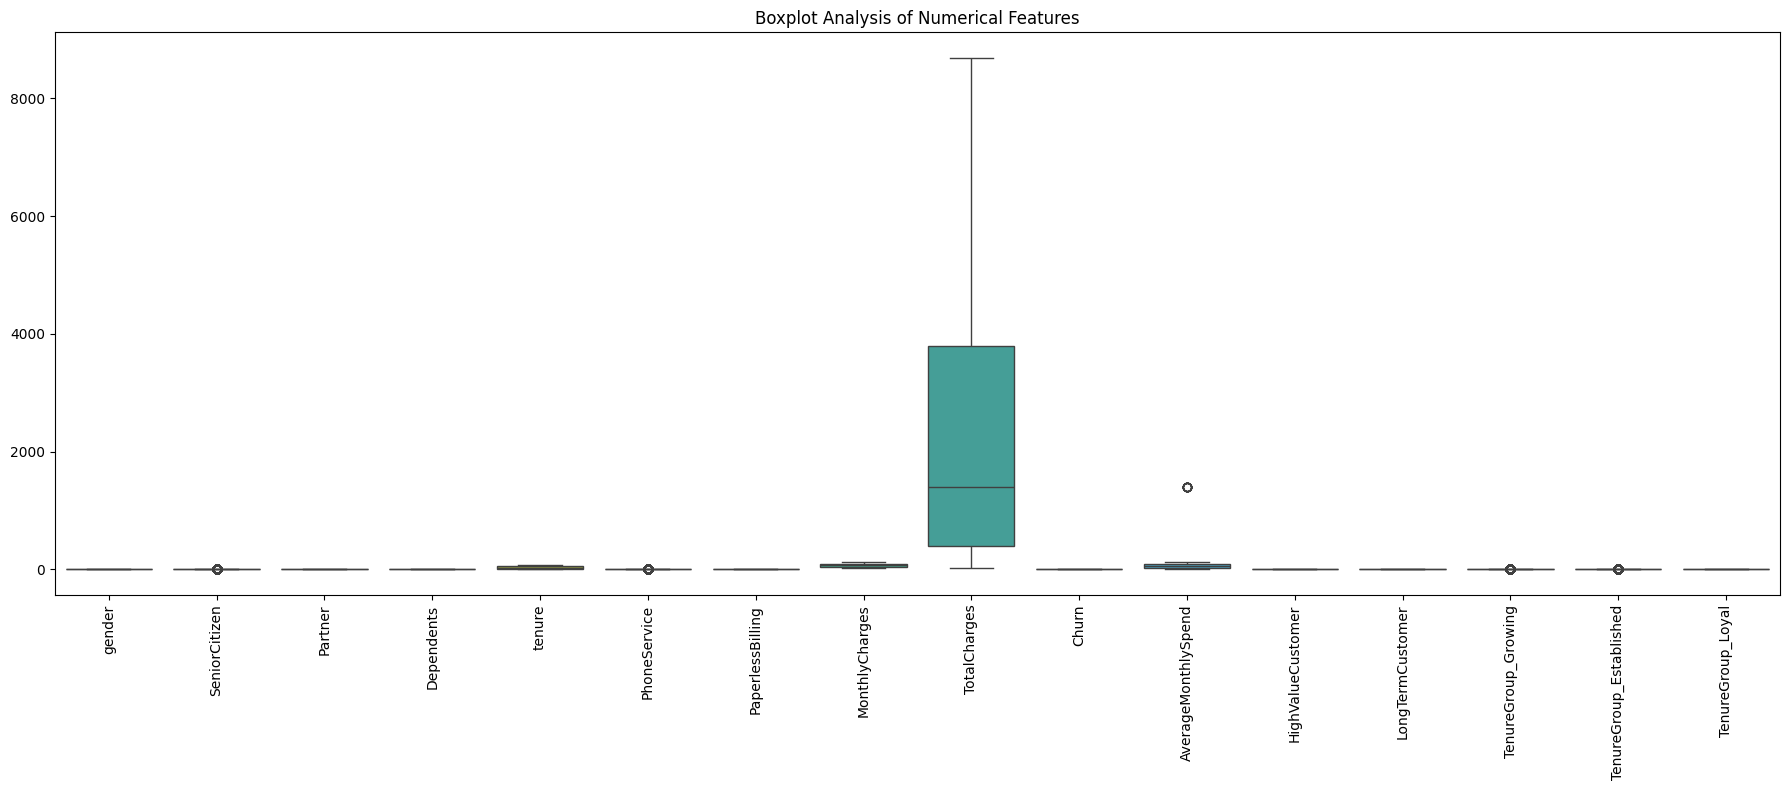

In [5]:
# Create boxplots for numerical features

plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df[numerical_columns]
)

# Rotate labels for readability
plt.xticks(rotation=90)

# Add title
plt.title(
    "Boxplot Analysis of Numerical Features"
)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

## Observation

The boxplots provide a visual representation of the distribution of numerical features.

Potential outliers appear as points beyond the whiskers of the boxplot.

Features exhibiting extreme values will be analyzed quantitatively using the IQR method in the next section.

# IQR-Based Outlier Detection

The Interquartile Range (IQR) method is a widely used statistical technique for identifying potential outliers.

Definitions:

- Q1 = 25th Percentile
- Q3 = 75th Percentile
- IQR = Q3 − Q1

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any observation outside these bounds is considered a potential outlier.

In [6]:
# Create empty list to store results

outlier_results = []

# Loop through numerical columns

for column in numerical_columns:

    # Calculate quartiles

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    # Calculate bounds

    lower_bound = Q1 - (1.5 * IQR)

    upper_bound = Q3 + (1.5 * IQR)

    # Count outliers

    outlier_count = df[
        (df[column] < lower_bound)
        |
        (df[column] > upper_bound)
    ].shape[0]

    # Store results

    outlier_results.append(
        [
            column,
            outlier_count
        ]
    )

# Create dataframe

outlier_df = pd.DataFrame(
    outlier_results,
    columns=[
        "Feature",
        "Outlier_Count"
    ]
)

# Display results

outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

,Feature,Outlier_Count
14,TenureGroup_Established,1594
1,SeniorCitizen,1142
13,TenureGroup_Growing,1024
5,PhoneService,682
10,AverageMonthlySpend,11
3,Dependents,0
2,Partner,0
0,gender,0
7,MonthlyCharges,0
6,PaperlessBilling,0


## Observation

The table above shows the number of observations identified as outliers in each numerical feature using the IQR method.

Features with higher outlier counts may require additional investigation before model training.

The next step calculates the percentage of outliers relative to the total dataset size.

# Outlier Percentage Analysis

Raw outlier counts alone may be misleading.

Therefore, the percentage of outliers is calculated to understand the impact on the dataset.

In [7]:
# Calculate outlier percentage

outlier_df["Outlier_Percentage"] = (
    outlier_df["Outlier_Count"]
    /
    len(df)
) * 100

# Sort by percentage

outlier_df = outlier_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

# Display table

outlier_df

,Feature,Outlier_Count,Outlier_Percentage
14,TenureGroup_Established,1594,22.632401
1,SeniorCitizen,1142,16.214681
13,TenureGroup_Growing,1024,14.539259
5,PhoneService,682,9.683374
10,AverageMonthlySpend,11,0.156183
3,Dependents,0,0.000000
2,Partner,0,0.000000
0,gender,0,0.000000
7,MonthlyCharges,0,0.000000
6,PaperlessBilling,0,0.000000


## Observation

The percentage table indicates the proportion of records identified as outliers for each feature.

A small percentage typically suggests limited impact on model training, while large percentages may indicate highly skewed distributions or special business cases.

The final decision on outlier treatment will be based on both statistical evidence and business understanding.

# Outlier Treatment Decision

The IQR analysis identified potential outliers in several variables.

However, many of these features are binary encoded variables (0/1) and engineered categorical indicators.

For binary variables, IQR-based outlier detection is not statistically appropriate because valid category values may be incorrectly flagged as outliers.

Therefore, outlier treatment will only be evaluated for continuous numerical variables.

In [8]:
# Continuous numerical variables only

continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend"
]

continuous_features

['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

## Observation

The following variables are continuous numerical features:

- tenure
- MonthlyCharges
- TotalCharges
- AverageMonthlySpend

Only these variables will be considered for final outlier treatment decisions.

# Continuous Feature Outlier Analysis

In [9]:
# Create outlier summary for continuous variables only

continuous_outliers = []

for column in continuous_features:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)

    upper_bound = Q3 + (1.5 * IQR)

    outlier_count = df[
        (df[column] < lower_bound)
        |
        (df[column] > upper_bound)
    ].shape[0]

    outlier_percentage = (
        outlier_count
        /
        len(df)
    ) * 100

    continuous_outliers.append(
        [
            column,
            outlier_count,
            round(outlier_percentage, 2)
        ]
    )

continuous_outlier_df = pd.DataFrame(
    continuous_outliers,
    columns=[
        "Feature",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)

continuous_outlier_df

,Feature,Outlier_Count,Outlier_Percentage
0,tenure,0,0.00
1,MonthlyCharges,0,0.00
2,TotalCharges,0,0.00
3,AverageMonthlySpend,11,0.16


# Final Outlier Treatment Decision

Outlier analysis was performed using the Interquartile Range (IQR) method.

Results indicate:

- No outliers were detected in tenure.
- No outliers were detected in MonthlyCharges.
- No outliers were detected in TotalCharges.
- AverageMonthlySpend contains only 11 outlier observations.

This represents approximately 0.16% of the entire dataset.

Business Decision:

The identified observations are likely to represent genuine customer spending behavior rather than data quality issues.

Since the percentage of outliers is extremely small and customer churn datasets often contain naturally occurring extreme values, the outliers will be retained.

No outlier removal or capping will be performed.

The dataset will be preserved in its original form to avoid unnecessary information loss.

# Save Final Dataset for Model Building

The final cleaned dataset will be exported for machine learning model development.

This dataset includes:

- Missing value treatment
- Feature encoding
- Feature engineering
- Outlier assessment

The exported dataset will be used in the model building stage.

In [10]:
# Save final processed dataset

df.to_csv(
    "../data/final_telco_churn.csv",
    index=False
)

print(
    "Final dataset saved successfully."
)

Final dataset saved successfully.


# Outlier Analysis Conclusion

Key Findings:

- No significant outliers exist within the continuous numerical features.
- Binary and engineered categorical variables were excluded from outlier treatment because IQR is not suitable for binary data.
- Only 11 observations were identified as potential outliers in AverageMonthlySpend.
- The outlier percentage is extremely low (0.16%).

Final Decision:

The dataset is retained without outlier removal.

The final dataset is now ready for machine learning model development.